In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.datasets import make_blobs

In [ ]:
X, y = make_blobs(n_samples=50, centers=2, random_state=1, cluster_std=2)
y = np.where(y == 0, -1, 1).astype(float)

In [ ]:
#define variables
m, n = X.shape
K = np.dot(X, X.T)
P = matrix(np.outer(y, y) * K)
q = matrix(-np.ones((m, 1)))
G = matrix(-np.eye(m))
h = matrix(np.zeros(m))
A = matrix(y.reshape(1, -1))
b = matrix(np.zeros(1))

In [ ]:
# 3. Solve QP
solvers.options['show_progress'] = False # Suppress solver output
solution = solvers.qp(P, q, G, h, A, b)

In [ ]:
# 4. Extract Parameters
alphas = np.array(solution['x']).flatten()

# Filter out very small alpha values (close to zero)
# Support vectors have non-zero lagrange multipliers
sv_indices = alphas > 1e-5
ind = np.arange(len(alphas))[sv_indices]
alpha_sv = alphas[sv_indices]
sv = X[sv_indices]
sv_y = y[sv_indices]

print(f"{len(alpha_sv)} support vectors found.")

# Calculate Weights (w)
# w = sum(alpha_i * y_i * x_i)
w = np.zeros(n)
for i in range(len(alpha_sv)):
    w += alpha_sv[i] * sv_y[i] * sv[i]

# Calculate Bias (b)
# For any support vector: y_i(w.x_i + b) = 1  =>  b = y_i - w.x_i
# We average it over all support vectors for numerical stability
b = 0
for i in range(len(alpha_sv)):
    b += sv_y[i] - np.dot(w, sv[i])
b /= len(alpha_sv)

3 support vectors found.


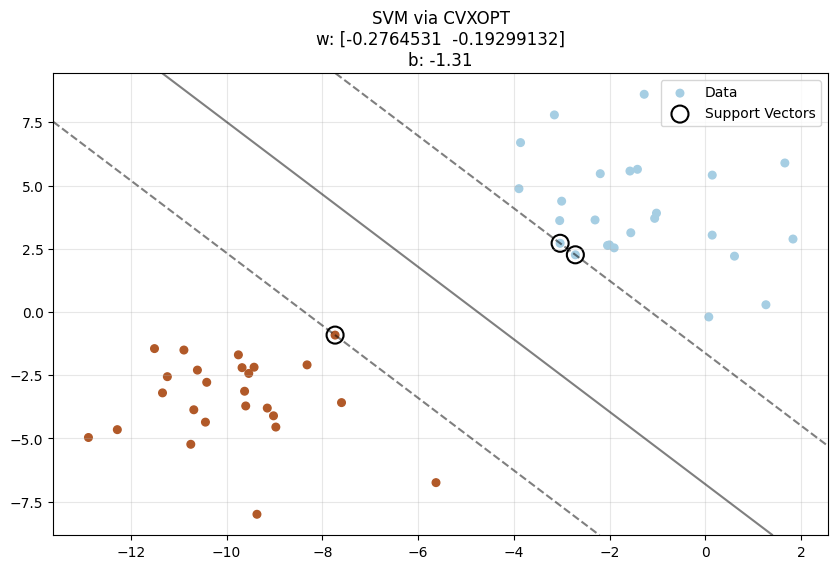

Calculated Weights (w): [-0.2764531  -0.19299132]
Calculated Bias (b): -1.3145528590369076


In [ ]:
# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, s=30, label='Data')

# Plot Support Vectors (Circle them)
plt.scatter(sv[:, 0], sv[:, 1], s=150, linewidth=1.5,
            facecolors='none', edgecolors='k', label='Support Vectors')

# Plot Decision Boundary and Margins
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Evaluate w.x + b
Z = np.dot(xy, w) + b
Z = Z.reshape(XX.shape)

# Contour plot
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

plt.title(f"SVM via CVXOPT\nw: {w}\nb: {b:.2f}")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Calculated Weights (w): {w}")
print(f"Calculated Bias (b): {b}")

### 6. Implementing SVM with Scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets


# Initialize and train the SVC model
svm_model = SVC(kernel='linear', C=1.0) # Using a linear kernel for comparison with custom implementation
svm_model.fit(X, y)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Scikit-learn SVC Accuracy: {accuracy:.4f}")

# Extract support vectors, weights, and bias from the scikit-learn model
sv_sklearn = svm_model.support_vectors_
w_sklearn = svm_model.coef_[0]
b_sklearn = svm_model.intercept_[0]

Scikit-learn SVC Accuracy: 1.0000


### 7. Plotting Scikit-learn SVM Decision Boundary

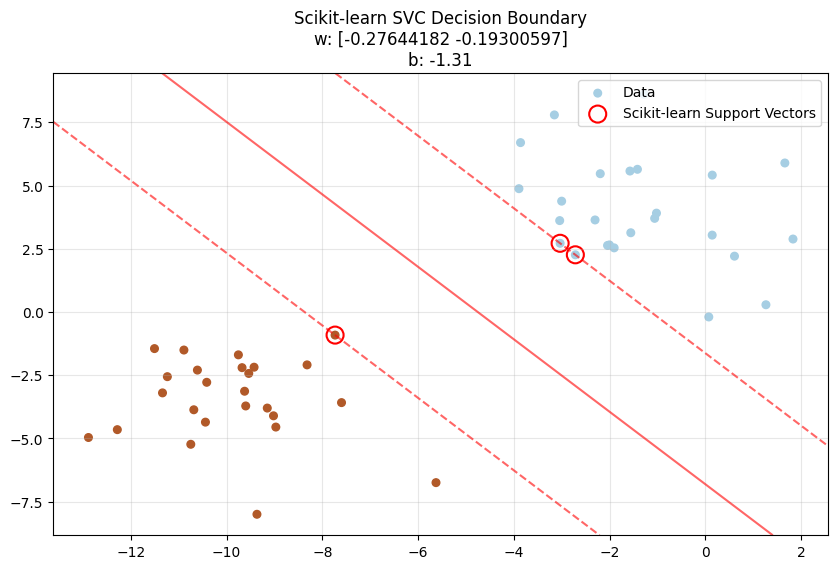

Scikit-learn Weights (w): [-0.27644182 -0.19300597]
Scikit-learn Bias (b): -1.3144823200497042


In [ ]:
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, s=30, label='Data')

# Plot Support Vectors from scikit-learn (Circle them)
plt.scatter(sv_sklearn[:, 0], sv_sklearn[:, 1], s=150, linewidth=1.5,
            facecolors='none', edgecolors='red', label='Scikit-learn Support Vectors')

# Plot Decision Boundary and Margins for scikit-learn SVM
ax = plt.gca()
xlim_sklearn = ax.get_xlim()
ylim_sklearn = ax.get_ylim()

xx_sklearn = np.linspace(xlim_sklearn[0], xlim_sklearn[1], 30)
yy_sklearn = np.linspace(ylim_sklearn[0], ylim_sklearn[1], 30)
YY_sklearn, XX_sklearn = np.meshgrid(yy_sklearn, xx_sklearn)
xy_sklearn = np.vstack([XX_sklearn.ravel(), YY_sklearn.ravel()]).T

Z_sklearn = np.dot(xy_sklearn, w_sklearn) + b_sklearn
Z_sklearn = Z_sklearn.reshape(XX_sklearn.shape)

ax.contour(XX_sklearn, YY_sklearn, Z_sklearn, colors='red', levels=[-1, 0, 1], alpha=0.6, linestyles=['--', '-', '--'])

plt.title(f"Scikit-learn SVC Decision Boundary\nw: {w_sklearn}\nb: {b_sklearn:.2f}")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Scikit-learn Weights (w): {w_sklearn}")
print(f"Scikit-learn Bias (b): {b_sklearn}")

In [ ]:
print("Difference Between W and W_Sklearn: ", w - w_sklearn)
print("Difference Between B and B_Sklearn: ", b - b_sklearn)

Difference Between W and W_Sklearn:  [-1.12838231e-05  1.46526761e-05]
Difference Between B and B_Sklearn:  -7.053898720332796e-05
